
# TF‑IDF + XGBoost (GPU‑ready) — Robust, Dataset‑Swappable Notebook

**Updated:** 2025-10-12 23:48 UTC  

This notebook is a cleaned‑up version that:
- Uses **XGBoost ≥ 2.0** GPU setup correctly (`tree_method="hist", device="cuda"`).
- Moves **early stopping** to `.fit(...)` so it always works.
- Avoids the **Wrong key type** error by extracting lists/arrays from `datasets.Dataset` **before** `train_test_split`.
- Supports easy dataset swapping (defaults to `yelp_review_full` with 5 classes and star‑label names).

> If you switch datasets, just update the `DATASET_ID` and optionally `TEXT_COL`, `LABEL_COL`, and `LABEL_NAMES` below.


In [1]:

import os, sys, platform, numpy as np, pandas as pd
import sklearn, xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import itertools

print("Python:", sys.version.replace("\n"," "))
print("OS:", platform.platform())
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("xgboost:", xgb.__version__)
try:
    import torch
    print("PyTorch:", torch.__version__)
except Exception:
    print("PyTorch: not installed")


Python: 3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]
OS: Linux-6.6.97+-x86_64-with-glibc2.35
NumPy: 2.0.2
pandas: 2.2.2
scikit-learn: 1.6.1
xgboost: 3.0.5
PyTorch: 2.8.0+cu126


In [2]:

# Optional: verify GPU in Colab
try:
    import subprocess, shutil
    if shutil.which("nvidia-smi"):
        print(subprocess.check_output(["nvidia-smi", "-L"]).decode())
    else:
        print("nvidia-smi not found — GPU may be unavailable in this runtime.")
except Exception as e:
    print("nvidia-smi check error:", e)

# Install/Import datasets (avoid noisy reinstall if already present)
try:
    from datasets import load_dataset
except Exception:
    import sys
    !pip -q install datasets
    from datasets import load_dataset


GPU 0: Tesla T4 (UUID: GPU-40efecf3-e35a-b369-8a73-56e252f98efb)



In [3]:
# ── CONFIG ─────────────────────────────────────────────────────────────────────
DATASET_ID = "yelp_review_full"   # e.g. "yelp_review_full", "ag_news", custom CSV via load_dataset("csv", ...)
TEXT_COL   = "text"               # column name for text
LABEL_COL  = "label"              # column name for labels

# Label names for yelp_review_full (0..4) → human-friendly mapping for report
LABEL_NAMES = ["1 star", "2 stars", "3 stars", "4 stars", "5 stars"]

# Random seed
RANDOM_STATE = 42


TFIDF_KW = dict(
    stop_words="english",
    ngram_range=(1,2),     # keep bigrams
    max_features=50_000,  # ↓ from 100_000 to reduce memory usage
    min_df=3,              # ↓ from 5 to keep more signal
    max_df=0.95,
    sublinear_tf=True,     # NEW: log(1+tf)
    smooth_idf=True,       # NEW: classic smoothing
    dtype=np.float32,
)

# XGBoost configuration — GPU‑ready for 2.x
XGB_KW = dict(
    objective="multi:softprob",
    n_estimators=2000,        # high cap; ES will stop earlier
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    tree_method="hist",       # correct for XGBoost 2.x (GPU selected via device)
    device="cuda",            # "cuda" for GPU, "cpu" to force CPU
    eval_metric="mlogloss",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

In [4]:
from datasets import load_dataset
import numpy as np
from sklearn.model_selection import train_test_split
import random # Import random for sampling

RANDOM_STATE = 42
TEXT_COL  = "text"
LABEL_COL = "label"

# 1) Load
ds = load_dataset("yelp_review_full")

# 2) Extract into plain containers (NO HF indexing later)
X_all_list  = list(ds["train"][TEXT_COL])                        # list[str]
y_all_arr   = np.asarray(ds["train"][LABEL_COL], dtype=np.int64) # np.ndarray[int64]
X_test_list = list(ds["test"][TEXT_COL])                         # list[str]
y_test_arr  = np.asarray(ds["test"][LABEL_COL], dtype=np.int64)  # np.ndarray[int64]

# (Optional) prevent accidental reuse of HF dataset objects
del ds

# NEW: Sample 10% of the training data
sample_size = int(len(X_all_list) * 0.10)
random.seed(RANDOM_STATE)
sample_indices = random.sample(range(len(X_all_list)), sample_size)

X_all_list_sampled = [X_all_list[i] for i in sample_indices]
y_all_arr_sampled = y_all_arr[sample_indices]

# Use sampled data for the rest of the process
X_all_list = X_all_list_sampled
y_all_arr = y_all_arr_sampled


# 3) Safety checks — these MUST pass
assert isinstance(X_all_list, list), f"type(X_all_list)={type(X_all_list)}"
assert isinstance(X_test_list, list), f"type(X_test_list)={type(X_test_list)}"
assert isinstance(y_all_arr, np.ndarray), f"type(y_all_arr)={type(y_all_arr)}"
assert y_all_arr.dtype == np.int64, f"dtype(y_all_arr)={y_all_arr.dtype}"

# 4) Split — ONLY lists/ndarrays here
X_train_list, X_val_list, y_train_arr, y_val_arr = train_test_split(
    X_all_list, y_all_arr, test_size=0.10, stratify=y_all_arr, random_state=RANDOM_STATE
)

# 5) Extra safety: force containers back to list/ndarray in case sklearn returns views
X_train_list = list(X_train_list)
X_val_list   = list(X_val_list)
X_test_list  = list(X_test_list)
y_train_arr  = np.asarray(y_train_arr, dtype=np.int64)
y_val_arr    = np.asarray(y_val_arr, dtype=np.int64)
y_test_arr   = np.asarray(y_test_arr, dtype=np.int64)

print("Sizes → Train:", len(X_train_list), " Val:", len(X_val_list), " Test:", len(X_test_list))
print("Label ranges →",
      "train:", (int(y_train_arr.min()), int(y_train_arr.max())),
      "val:",   (int(y_val_arr.min()),   int(y_val_arr.max())),
      "test:",  (int(y_test_arr.min()),  int(y_test_arr.max())))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

yelp_review_full/train-00000-of-00001.pa(…):   0%|          | 0.00/299M [00:00<?, ?B/s]

yelp_review_full/test-00000-of-00001.par(…):   0%|          | 0.00/23.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/650000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Sizes → Train: 58500  Val: 6500  Test: 50000
Label ranges → train: (0, 4) val: (0, 4) test: (0, 4)


In [5]:
# Fit TF-IDF on TRAIN only; transform Val/Test
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

tfidf = TfidfVectorizer(**TFIDF_KW)

# ✅ Use the "_list" variables that are pure Python lists
Xtr = tfidf.fit_transform(X_train_list)
Xva = tfidf.transform(X_val_list)
Xte = tfidf.transform(X_test_list)

print("Shapes → Xtr:", Xtr.shape, " Xva:", Xva.shape, " Xte:", Xte.shape)

Shapes → Xtr: (58500, 50000)  Xva: (6500, 50000)  Xte: (50000, 50000)


In [6]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
import xgboost as xgb

# 1) Class weights → per-example sample weights (using the *_arr labels)
classes = np.unique(y_train_arr)
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_arr)
class_weight_map = {c: w for c, w in zip(classes, class_weights)}
sample_weights = np.array([class_weight_map[c] for c in y_train_arr], dtype=np.float32)
print("Class weights:", class_weight_map)

# 2) Build classifier (GPU-correct for 2.x)
num_class = int(classes.max() + 1)  # assumes labels are 0..K-1
xgb_version = xgb.__version__

# Copy your base params dict; ensure it exists (from earlier cell)
params = dict(XGB_KW)  # XGB_KW defined earlier
params["num_class"] = num_class

# In XGBoost ≥ 2.0, early_stopping_rounds belongs in the constructor;
# in older versions, it's passed to .fit(...).
def _version_tuple(v):
    # robust parse (handles "2.1.1", "2.0.0rc2", etc.)
    parts = []
    for p in v.split("."):
        num = "".join(ch for ch in p if ch.isdigit())
        parts.append(int(num) if num else 0)
    return tuple(parts[:3] + [0]*(3-len(parts)))

if _version_tuple(xgb_version) >= (2, 0, 0):
    params["early_stopping_rounds"] = 50
    clf = XGBClassifier(**params)
    print(f"Training XGBoost {xgb_version} (device={params.get('device')}, tree_method={params.get('tree_method')})…")
    clf.fit(
        Xtr, y_train_arr,
        sample_weight=sample_weights,
        eval_set=[(Xva, y_val_arr)],
        verbose=100,
    )
else:
    clf = XGBClassifier(**params)
    print(f"Training XGBoost {xgb_version} (device={params.get('device')}, tree_method={params.get('tree_method')})…")
    clf.fit(
        Xtr, y_train_arr,
        sample_weight=sample_weights,
        eval_set=[(Xva, y_val_arr)],
        early_stopping_rounds=50,  # <— older API expects it here
        verbose=100,
    )

# 3) (Optional) confirm device
try:
    print("Booster attributes:", clf.get_booster().attributes())
except Exception as e:
    print("Could not read booster attributes:", e)

Class weights: {np.int64(0): np.float64(1.0126363164272114), np.int64(1): np.float64(0.9965079635465462), np.int64(2): np.float64(0.994052676295667), np.int64(3): np.float64(1.0015408320493067), np.int64(4): np.float64(0.9954905130604952)}
Training XGBoost 3.0.5 (device=cuda, tree_method=hist)…
[0]	validation_0-mlogloss:8.13930
[49]	validation_0-mlogloss:28.84519
Booster attributes: {'best_iteration': '0', 'best_score': '8.13930190023092'}


Validation Accuracy: 0.3162

Validation Classification Report
              precision    recall  f1-score   support

      1 star     0.5219    0.2975    0.3790      1284
     2 stars     0.2772    0.2914    0.2841      1304
     3 stars     0.2669    0.2232    0.2431      1308
     4 stars     0.2698    0.3706    0.3122      1298
     5 stars     0.3421    0.3982    0.3680      1306

    accuracy                         0.3162      6500
   macro avg     0.3356    0.3162    0.3173      6500
weighted avg     0.3350    0.3162    0.3171      6500



/usr/local/lib/python3.12/dist-packages/xgboost/core.py:729: UserWarning: [02:47:57] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


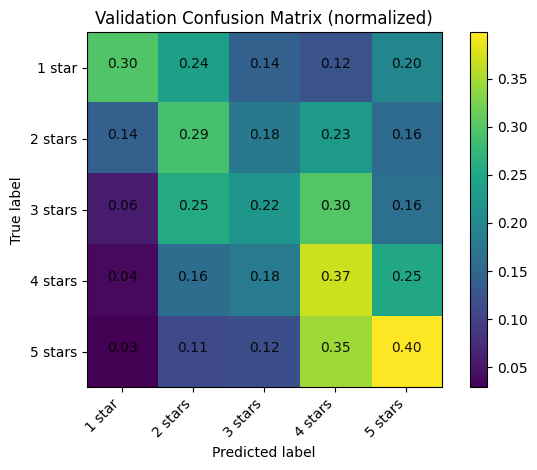

In [7]:
import numpy as np
import itertools
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Helper: confusion matrix plot
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix'):
    if normalize:
        with np.errstate(all='ignore'):
            cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
            cm = np.nan_to_num(cm)
    plt.figure()
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha='right')
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center", alpha=0.9)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

# ---- Validation performance (use *_arr variables) ----
y_val_pred  = clf.predict(Xva)
y_val_proba = clf.predict_proba(Xva)  # optional sanity check: y_val_proba.shape == (len(y_val_arr), num_class)

val_acc = accuracy_score(y_val_arr, y_val_pred)
print(f"Validation Accuracy: {val_acc:.4f}\n")

# Use label names only if they match the number of classes
target_names = LABEL_NAMES if ('LABEL_NAMES' in globals() and len(LABEL_NAMES) == num_class) else [str(i) for i in range(num_class)]

print("Validation Classification Report")
print(classification_report(y_val_arr, y_val_pred, target_names=target_names, digits=4, zero_division=0))

cm_val = confusion_matrix(y_val_arr, y_val_pred)
plot_confusion_matrix(cm_val, classes=target_names, normalize=True,
                      title="Validation Confusion Matrix (normalized)")



In [8]:

# Quick inference demo
samples = [
    "The food was terrible and the service was slow.",
    "Absolutely wonderful experience — highly recommend!",
    "It was okay; some parts were fine, others meh."
]
X_samples = tfidf.transform(samples)
preds = clf.predict(X_samples)
probs = clf.predict_proba(X_samples)

print("\nSample Inference:")
for txt, yhat, p in zip(samples, preds, probs):
    label = (target_names[yhat] if target_names else str(yhat))
    print(f"- {label:>7} | {txt[:80]}...  (top prob={p[yhat]:.3f})")



Sample Inference:
- 5 stars | The food was terrible and the service was slow....  (top prob=0.503)
- 5 stars | Absolutely wonderful experience — highly recommend!...  (top prob=0.503)
- 5 stars | It was okay; some parts were fine, others meh....  (top prob=0.503)
